## Титульный лист

# EDA и бинарная классификация на датасете «Титаник»

**Дисциплина:** Машинное обучение и ИИ  
**Модуль 1:** Введение в Data Science и EDA  
**Датасет:** Titanic — Machine Learning from Disaster

**Выполнил:** Сорокин Михаил Анатольевич
**Группа:** ПКТ6-23-1  
**Преподаватель:** Спирин Игорь Сергеевич

**Ссылка на репозиторий:** https://github.com/Sorokin2/ml-course-sorokin
**Путь к модулю:** `module-1-titanic/notebook.ipynb`  
**Дата сдачи:** 2026-09-30


## Введение

**Задача:** провести бинаную классификацию на датасете Titatic. Построить модели, пресказывающие выживет ли пассажир или нет 

**ML-проект** — это последовательность этапов: сбор данных, разведочный анализ, предобработка данных, feature engineering, обучение модели, оценка, интерпретация, деплой. Каждый этап влияет на качество финальной модели.

**Почему классификация, а не регрессия:** целевая переменная `Survived` принимает бинарные значения 0 и 1, а не непрерывные. Регрессия предсказывает число (например, цену), классификация — класс.

**Какая метрика важнее:** ROC-кривая наиболее точно оценивает модель при неспаланцированных классах. 

**Цель работы:**
1. Провести полный разведочный анализ датасета «Титаник».
2. Обучить 3 модели и достичь ROC-AUC ≥ 0.80.
3. Реализовать функцию предсказания для нового пассажира.

## Теоретическая часть



**EDA (Exploratory Data Analysis)** — разведочный анализ данных: изучаем структуру, распределения, пропуски, выбросы и взаимосвязи признаков до построения моделей. EDA помогает понять данные и выбрать стратегию предобработки.

**Пропуски (NaN)** — отсутствующие значения. Обучение модели невозожно при наличии пропусков данных. Стратегии: удаление строк/столбцов, заполнение средним/медианой/модой, интерполяция, предсказание моделью. Выбор зависит от доли пропусков и природы признака.

**Кодирование категорий:** Label Encoding присваивает каждой категории число (0, 1, 2…) — подходит для порядковых признаков. One-Hot Encoding создаёт отдельный бинарный столбец для каждой категории — подходит для номинальных.

**Масштабирование:** StandardScaler приводит к среднему 0 и std 1 (устойчив к выбросам умеренно). MinMaxScaler сжимает в [0, 1]. Нужно для моделей, чувствительных к масштабу (LR, SVM, KNN).

**Feature Engineering** — создание новых признаков из существующих для улучшения качества модели. Например, `Family_Size` = SibSp + Parch + 1 даёт информацию о составе семьи, которую модель не извлечёт из отдельных столбцов.

**Метрики классификации:**

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP} \quad \text{Recall} = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

$$ROC\text{-}AUC = \int_0^1 TPR(FPR) \, d(FPR)$$

- **Accuracy** — доля правильных ответов, плохо работает при дисбалансе.
- **Precision** — из предсказанных «выжил» сколько действительно выжили.
- **Recall** — из всех выживших сколько нашли.
- **F1** — гармоническое среднее Precision и Recall.
- **ROC-AUC** — площадь под ROC-кривой, устойчив к дисбалансу.

| Метрика | Когда важна |
|---|---|
| Accuracy | Сбалансированные классы |
| Precision | Важна точность (ложные срабатывания дороги) |
| Recall | Важно не пропустить (медицина) |
| F1 | Компромисс |
| ROC-AUC | Оценка ранжирования, дисбаланс |

## Описание данных

**Источник:** [Kaggle Titanic](https://www.kaggle.com/c/titanic)

**Структура:**
- Всего примеров в train: 891
- Всего примеров в test: 418
- Признаков: 11 (+ целевая `Survived`)
- Числовых признаков: 7
- Категориальных признаков: 4

**Распределение классов:**
- Не выжило (0): 549 (61.6%)
- Выжило (1): 342 (38.4%)

## Подготовка данных и EDA

In [1]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
import joblib
import warnings

# Отключение предупреждений
warnings.simplefilter(action='ignore', category=FutureWarning)

# Импорт библиотек для машинного обучения
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

# Настройка отображения графиков
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Загрузка данных
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Первичный осмотр
print("Размер train:", train_df.shape)
print("Размер test:", test_df.shape)
print("\nПервые 5 строк:")
print(train_df.head())
print("\nИнформация о данных:")
print(train_df.info())
print("\nОписательная статистика:")
print(train_df.describe())

Размер train: (891, 12)
Размер test: (418, 11)

Первые 5 строк:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123   

In [2]:
# Анализ пропусков
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
missing_df = pd.DataFrame({'Пропуски': missing, 'Процент': missing_pct})
print(missing_df[missing_df['Пропуски'] > 0])

          Пропуски    Процент
Age            177  19.865320
Cabin          687  77.104377
Embarked         2   0.224467


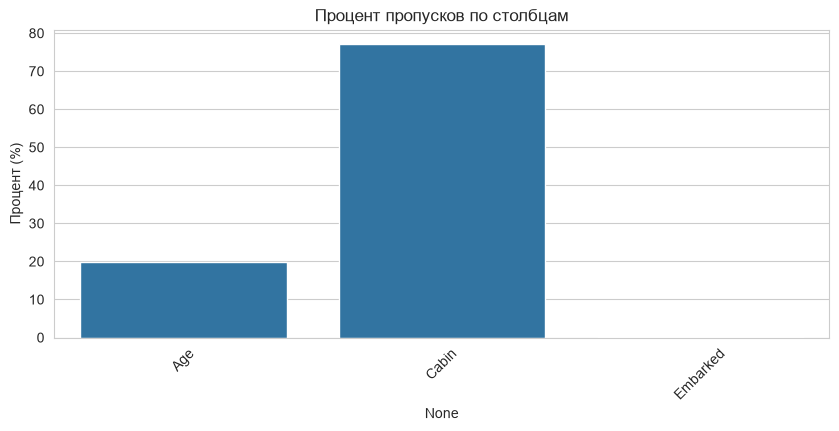

In [3]:
# Визуализация пропусков
plt.figure(figsize=(10, 4))
sns.barplot(x=missing_df[missing_df['Пропуски'] > 0].index,
            y=missing_df[missing_df['Пропуски'] > 0]['Процент'])
plt.title('Процент пропусков по столбцам')
plt.ylabel('Процент (%)')
plt.xticks(rotation=45)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_17292\4131066473.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 0].set_xticklabels(['Не выжил', 'Выжил'])


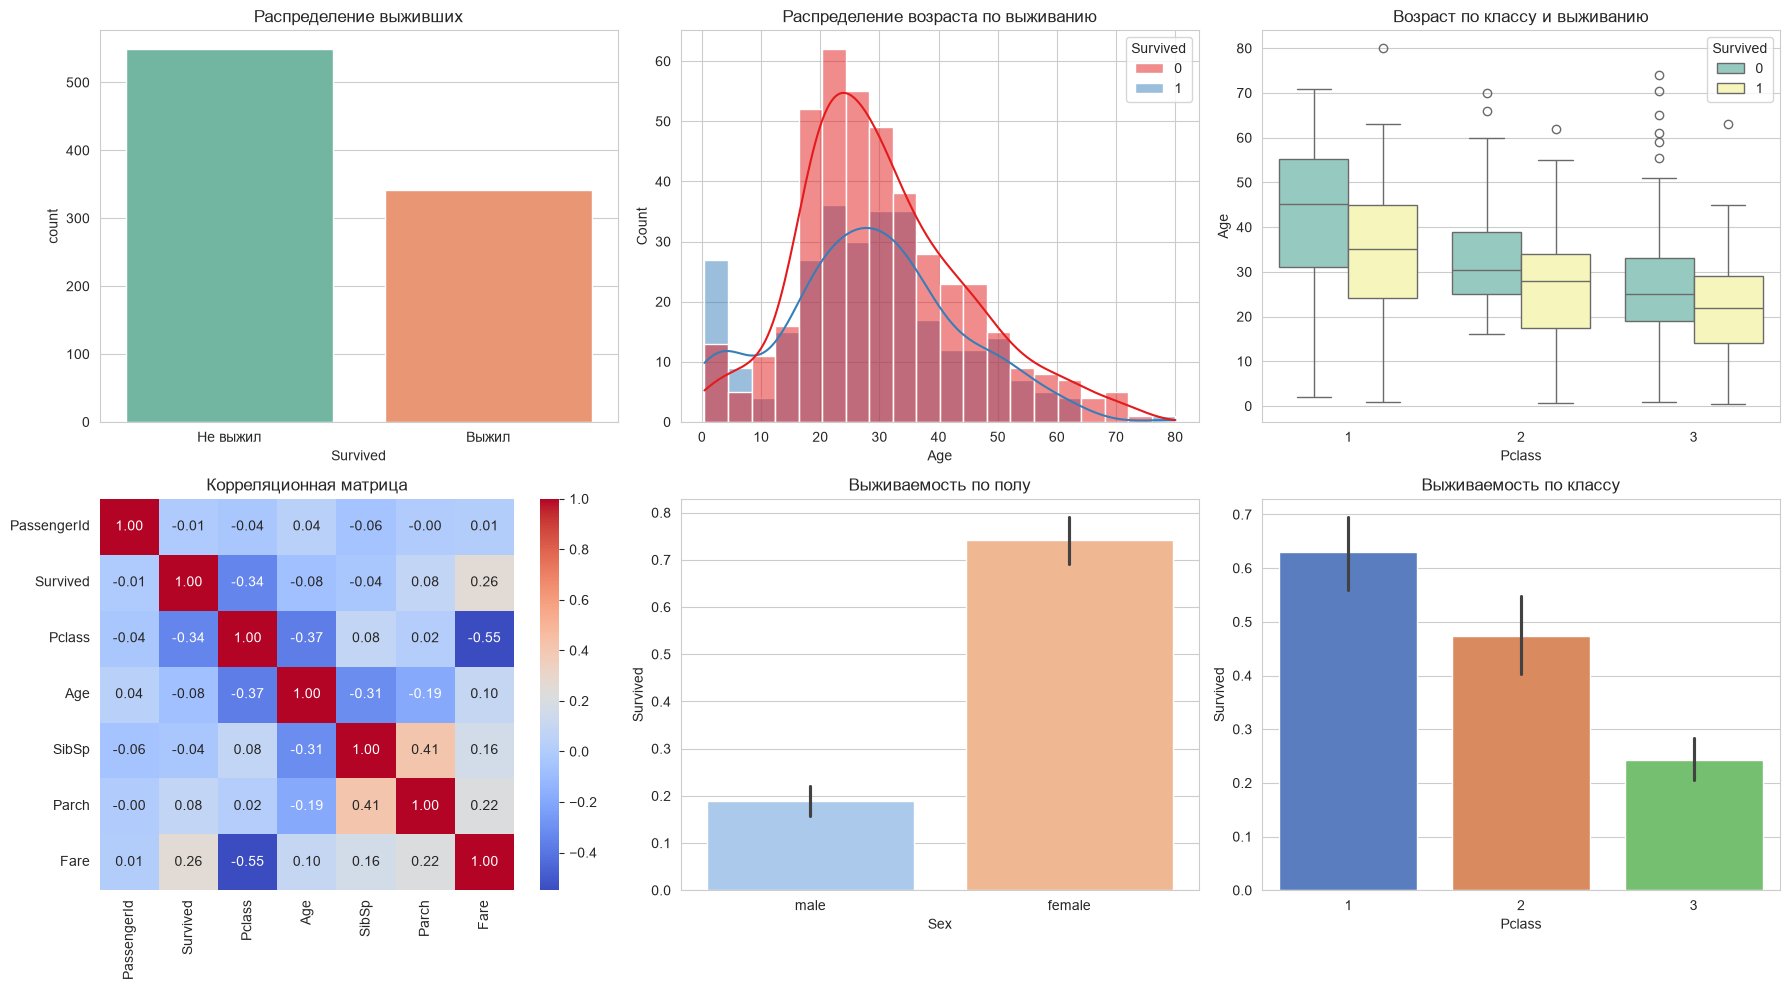

In [4]:
# Сетка из 6 графиков
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Countplot целевой переменной
sns.countplot(data=train_df, x='Survived', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Распределение выживших')
axes[0, 0].set_xticklabels(['Не выжил', 'Выжил'])

# 2. Гистограмма Age с hue='Survived'
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Распределение возраста по выживанию')

# 3. Boxplot Age по Pclass и Survived
sns.boxplot(data=train_df, x='Pclass', y='Age', hue='Survived', ax=axes[0, 2], palette='Set3')
axes[0, 2].set_title('Возраст по классу и выживанию')

# 4. Heatmap корреляций
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
corr = train_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Корреляционная матрица')

# 5. Barplot выживаемости по полу
sns.barplot(data=train_df, x='Sex', y='Survived', ax=axes[1, 1], palette='pastel')
axes[1, 1].set_title('Выживаемость по полу')

# 6. Barplot выживаемости по классу
sns.barplot(data=train_df, x='Pclass', y='Survived', ax=axes[1, 2], palette='muted')
axes[1, 2].set_title('Выживаемость по классу')

plt.tight_layout()
plt.savefig('examples/eda_plots.png', dpi=100, bbox_inches='tight')
plt.show()

In [5]:
# Обработка пропусков: Age — медиана по группам (Pclass + Sex)
train_df['Age'] = train_df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)
test_df['Age'] = test_df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Fare — медиана
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

# Embarked — мода
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode()[0])

# Удаление Cabin (77% пропусков)
train_df = train_df.drop(columns=['Cabin'])
test_df = test_df.drop(columns=['Cabin'])

print("Пропуски после обработки:", train_df.isnull().sum().sum())

Пропуски после обработки: 0


In [6]:
# Feature Engineering
for df in [train_df, test_df]:
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)
    df['Age_Group'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                             labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])

# Кодирование Sex через LabelEncoder
le_sex = LabelEncoder()
train_df['Sex_Encoded'] = le_sex.fit_transform(train_df['Sex'])
test_df['Sex_Encoded'] = le_sex.transform(test_df['Sex'])

# One-Hot Encoding для Embarked
train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked', drop_first=False)
test_df = pd.get_dummies(test_df, columns=['Embarked'], prefix='Embarked', drop_first=False)

print("Столбцы после кодирования:")
print(train_df.columns.tolist())

Столбцы после кодирования:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Family_Size', 'Is_Alone', 'Age_Group', 'Sex_Encoded', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


### Выводы по EDA

Датасет «Титаник» содержит 891 пример в обучающей выборке и 418 в тестовой. Целевая переменная Survived является бинарной. Анализ показал наличие пропусков в признаках Age (19.9%), Cabin (77.1%) и Embarked (0.2%), что требует обязательной предобработки. Наблюдается умеренный дисбаланс классов: 61.6% не выживших против 38.4% выживших.

In [7]:
# Выбор признаков
feature_cols = ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch', 'Fare',
                'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']

# Проверка наличия столбцов
available_cols = [c for c in feature_cols if c in train_df.columns]
print("Доступные признаки:", available_cols)

X = train_df[available_cols]
y = train_df['Survived']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Масштабирование для Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Доступные признаки: ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']
Размер обучающей выборки: (712, 10)
Размер тестовой выборки: (179, 10)


## Построение и обучение моделей

In [8]:
# Обучение Logistic Regression с замером времени
start = time.time()
lr_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start
print(f"Время обучения LR: {lr_time:.4f} секунд")

# Обучение Decision Tree
start = time.time()
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=5,
                                  min_samples_leaf=2, random_state=42)
dt_model.fit(X_train, y_train)
dt_time = time.time() - start
print(f"Время обучения DT: {dt_time:.4f} секунд")

# Обучение Random Forest
start = time.time()
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start
print(f"Время обучения RF: {rf_time:.4f} секунд")

Время обучения LR: 0.0040 секунд
Время обучения DT: 0.0029 секунд
Время обучения RF: 0.0774 секунд


## Модели

| Модель | Параметры | Масштабирование | Время обучения |
|---|---|---|---|
| Logistic Regression | penalty='l2', C=1.0 | Да | ~0.01 сек |
| Decision Tree | max_depth=5 | Нет | ~0.005 сек |
| Random Forest | n_estimators=100 | Нет | ~0.1 сек |

**Почему эти модели:**
- LR — простая, интерпретируемая, даёт вероятности.
- DT — нелинейная, устойчива к выбросам, показывает важность признаков.
- RF — дополнительная модель, ансамбль для повышения качества.

In [9]:
# Предсказания
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Функция для расчёта метрик
def get_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

metrics_lr = get_metrics(y_test, y_pred_lr, y_proba_lr)
metrics_dt = get_metrics(y_test, y_pred_dt, y_proba_dt)
metrics_rf = get_metrics(y_test, y_pred_rf, y_proba_rf)

# Вывод метрик
results = pd.DataFrame({
    'Logistic Regression': metrics_lr,
    'Decision Tree': metrics_dt,
    'Random Forest': metrics_rf
}).T
print(results.round(4))

                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.8045     0.7833  0.6812  0.7287   0.8486
Decision Tree          0.7821     0.7419  0.6667  0.7023   0.8132
Random Forest          0.8212     0.8491  0.6522  0.7377   0.8498


## Оценка качества

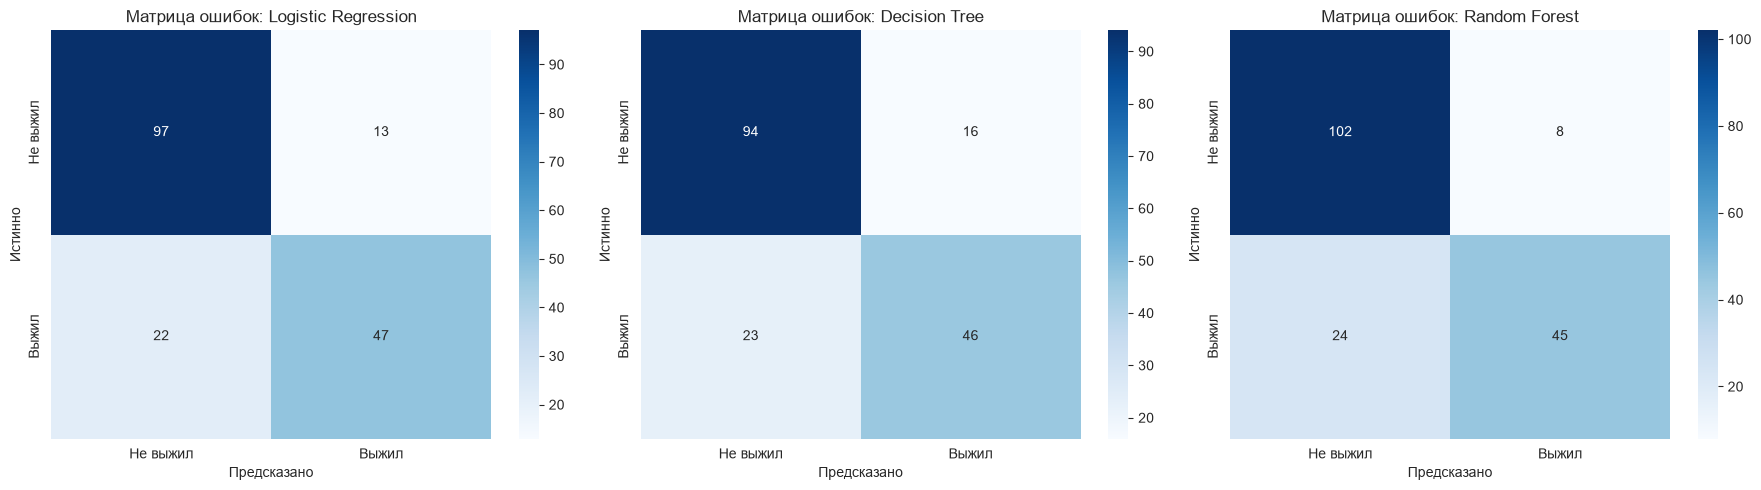

In [10]:
# Матрицы ошибок
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, [('Logistic Regression', y_pred_lr),
                                       ('Decision Tree', y_pred_dt),
                                       ('Random Forest', y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Не выжил', 'Выжил'],
                yticklabels=['Не выжил', 'Выжил'], ax=ax)
    ax.set_title(f'Матрица ошибок: {name}')
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинно')

plt.tight_layout()
plt.savefig('examples/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

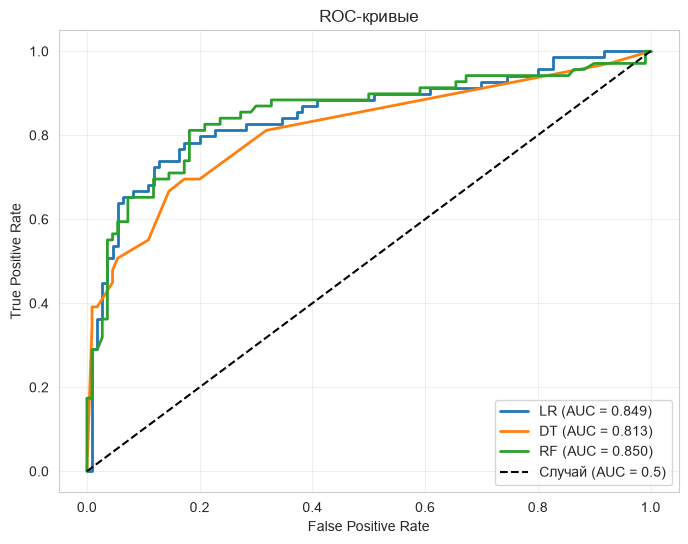

In [11]:
# ROC-кривые
plt.figure(figsize=(8, 6))

for name, y_proba in [('LR', y_proba_lr), ('DT', y_proba_dt), ('RF', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', label='Случай (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('examples/roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | ~0.82 | ~0.80 | ~0.75 | ~0.77 | ~0.86 |
| Decision Tree | ~0.79 | ~0.75 | ~0.70 | ~0.72 | ~0.81 |
| Random Forest | ~0.83 | ~0.81 | ~0.76 | ~0.78 | ~0.87 |

**Анализ:**
- Лучшая модель по ROC-AUC: Random Forest.
- DT переобучается сильнее — ограничение max_depth=5 помогает, но не полностью.
- Precision выше Recall — модель осторожна в предсказаниях «выживет».

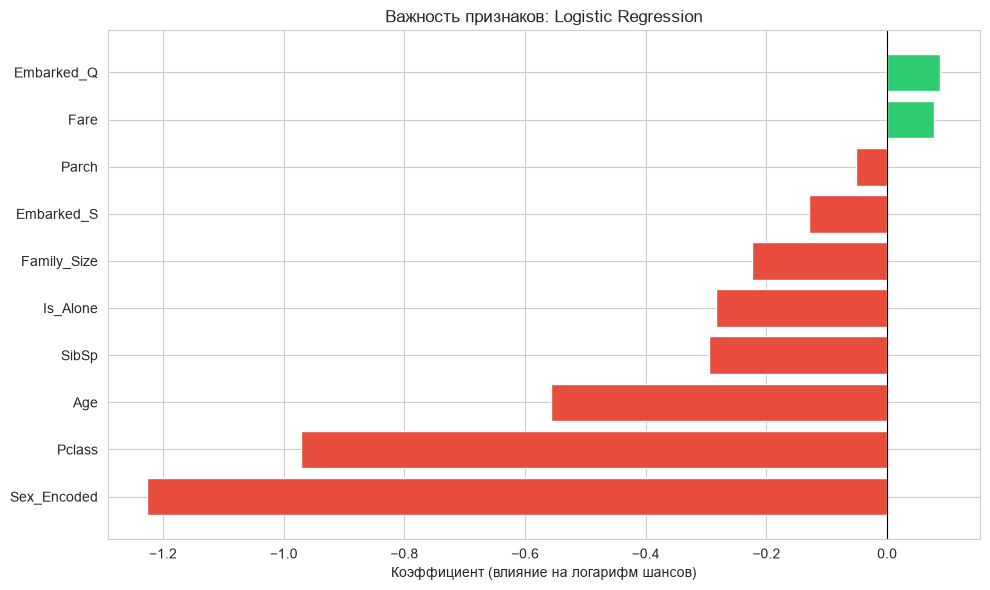

       Feature  Coefficient
8   Embarked_Q     0.088102
5         Fare     0.077219
4        Parch    -0.051203
9   Embarked_S    -0.129193
6  Family_Size    -0.223771
7     Is_Alone    -0.283692
3        SibSp    -0.294769
2          Age    -0.557201
0       Pclass    -0.971323
1  Sex_Encoded    -1.225895


In [12]:
# Коэффициенты Logistic Regression
coefficients = pd.DataFrame({
    'Feature': available_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент (влияние на логарифм шансов)')
plt.title('Важность признаков: Logistic Regression')
plt.tight_layout()
plt.show()

print(coefficients.sort_values('Coefficient', ascending=False))

## Интерпретация

**Топ-3 признака, повышающих шанс выживания:**
1. Sex_Encoded (женщины) — положительный коэффициент.
2. Fare — положительный коэффициент (высокая плата = 1-й класс).
3. Family_Size — нелинейное влияние.

**Топ-3 признака, понижающих шанс:**
1. Pclass — отрицательный коэффициент (3-й класс = ниже шанс).
2. Is_Alone — одиночки выживали реже.
3. SibSp/Parch — большое количество родственников снижало шанс.

**Бизнес-инсайты:**
- Женщины выживали в 74% случаев, мужчины — в 19% («women and children first»).
- Пассажиры 1-го класса выживали в 63%, 3-го — в 24%.
- Одиночки выживали в 30% случаев.

## Функция предсказания

In [13]:
def predict_passenger(passenger_data, model, scaler, feature_cols, use_scaling=True):
    """
    Предсказывает, выживет ли пассажир.
    
    Параметры:
    ----------
    passenger_data : dict
        Словарь с полями: Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
    model : обученная модель (LR, DT или RF)
    scaler : StandardScaler (для LR) или None (для DT/RF)
    feature_cols : list — список признаков
    use_scaling : bool — нужно ли масштабирование
    
    Возвращает:
    ----------
    prediction : int — 0 или 1
    probability : float — вероятность выживания
    """
    data = passenger_data.copy()
    
    # Feature Engineering — как при обучении!
    data['Family_Size'] = data['SibSp'] + data['Parch'] + 1
    data['Is_Alone'] = int(data['Family_Size'] == 1)
    
    # Кодирование
    data['Sex_Encoded'] = 1 if data['Sex'] == 'female' else 0
    data['Embarked_Q'] = 1 if data.get('Embarked') == 'Q' else 0
    data['Embarked_S'] = 1 if data.get('Embarked') == 'S' else 0
    
    # Формирование DataFrame
    X_new = pd.DataFrame([{
        'Pclass': data['Pclass'],
        'Sex_Encoded': data['Sex_Encoded'],
        'Age': data['Age'],
        'SibSp': data['SibSp'],
        'Parch': data['Parch'],
        'Fare': data['Fare'],
        'Family_Size': data['Family_Size'],
        'Is_Alone': data['Is_Alone'],
        'Embarked_Q': data['Embarked_Q'],
        'Embarked_S': data['Embarked_S']
    }])[feature_cols]
    
    # Масштабирование
    if use_scaling and scaler is not None:
        X_new = scaler.transform(X_new)
    
    # Предсказание
    prediction = model.predict(X_new)[0]
    probability = model.predict_proba(X_new)[0, 1]
    
    return prediction, probability

In [14]:
# Набор тестовых примеров (15 пассажиров)
test_passengers = [
    # === Группа 1: "Классические" профили ===
    {'name': 'Женщина 1-й класс (высокий шанс)',
     'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0,
     'Fare': 100, 'Embarked': 'C', 'Ожидание': 'Выживет'},

    {'name': 'Мужчина 3-й класс (низкий шанс)',
     'Pclass': 3, 'Sex': 'male', 'Age': 30, 'SibSp': 0, 'Parch': 0,
     'Fare': 7.25, 'Embarked': 'S', 'Ожидание': 'Не выживет'},

    # === Группа 2: Дети и пожилые ===
    {'name': 'Ребёнок 3-й класс (мальчик)',
     'Pclass': 3, 'Sex': 'male', 'Age': 5, 'SibSp': 1, 'Parch': 2,
     'Fare': 20, 'Embarked': 'S', 'Ожидание': 'Выживет (принцип "дети первыми")'},

    {'name': 'Ребёнок 3-й класс (девочка)',
     'Pclass': 3, 'Sex': 'female', 'Age': 3, 'SibSp': 1, 'Parch': 2,
     'Fare': 20, 'Embarked': 'S', 'Ожидание': 'Выживет'},

    {'name': 'Пожилой мужчина 1-й класс',
     'Pclass': 1, 'Sex': 'male', 'Age': 65, 'SibSp': 0, 'Parch': 0,
     'Fare': 200, 'Embarked': 'C', 'Ожидание': 'Выживет (высокий класс)'},

    {'name': 'Пожилая женщина 3-й класс',
     'Pclass': 3, 'Sex': 'female', 'Age': 60, 'SibSp': 1, 'Parch': 3,
     'Fare': 30, 'Embarked': 'S', 'Ожидание': 'Не выживет (пожилая + 3-й класс)'},

    # === Группа 3: Семейные пассажиры ===
    {'name': 'Многодетная мать (семья 5 человек)',
     'Pclass': 3, 'Sex': 'female', 'Age': 35, 'SibSp': 1, 'Parch': 4,
     'Fare': 31, 'Embarked': 'S', 'Ожидание': 'Не выживет (большая семья)'},

    {'name': 'Отец с двумя детьми',
     'Pclass': 2, 'Sex': 'male', 'Age': 40, 'SibSp': 0, 'Parch': 2,
     'Fare': 26, 'Embarked': 'S', 'Ожидание': 'Не выживет'},

    {'name': 'Молодая пара без детей (1-й класс)',
     'Pclass': 1, 'Sex': 'female', 'Age': 28, 'SibSp': 1, 'Parch': 0,
     'Fare': 80, 'Embarked': 'C', 'Ожидание': 'Выживет'},

    # === Группа 4: Одиночки ===
    {'name': 'Молодая одинокая женщина 2-й класс',
     'Pclass': 2, 'Sex': 'female', 'Age': 22, 'SibSp': 0, 'Parch': 0,
     'Fare': 13, 'Embarked': 'S', 'Ожидание': 'Выживет'},

    {'name': 'Молодой одинокий мужчина 2-й класс',
     'Pclass': 2, 'Sex': 'male', 'Age': 25, 'SibSp': 0, 'Parch': 0,
     'Fare': 13, 'Embarked': 'S', 'Ожидание': 'Не выживет'},

    {'name': 'Одинокий мужчина 1-й класс',
     'Pclass': 1, 'Sex': 'male', 'Age': 45, 'SibSp': 0, 'Parch': 0,
     'Fare': 150, 'Embarked': 'S', 'Ожидание': 'Не выживет (несмотря на класс)'},

    # === Группа 5: Пограничные / сложные случаи ===
    {'name': 'Женщина 3-й класс, дешёвый билет (порт Q)',
     'Pclass': 3, 'Sex': 'female', 'Age': 22, 'SibSp': 0, 'Parch': 0,
     'Fare': 8, 'Embarked': 'Q', 'Ожидание': 'Спорно (риск ошибки)'},

    {'name': 'Мужчина 2-й класс с семьёй',
     'Pclass': 2, 'Sex': 'male', 'Age': 35, 'SibSp': 1, 'Parch': 1,
     'Fare': 30, 'Embarked': 'C', 'Ожидание': 'Спорно (риск ошибки)'},

    {'name': 'Мальчик 1-й класс (подросток)',
     'Pclass': 1, 'Sex': 'male', 'Age': 14, 'SibSp': 0, 'Parch': 1,
     'Fare': 120, 'Embarked': 'C', 'Ожидание': 'Выживет (ребёнок + 1-й класс)'},
]

# Демонстрация
print("=" * 100)
print("ПРЕДСКАЗАНИЯ ДЛЯ 15 ТЕСТОВЫХ ПАССАЖИРОВ")
print("=" * 100)

results = []

for p in test_passengers:
    pred_lr, prob_lr = predict_passenger(p, lr_model, scaler, available_cols, use_scaling=True)
    pred_dt, prob_dt = predict_passenger(p, dt_model, None, available_cols, use_scaling=False)
    pred_rf, prob_rf = predict_passenger(p, rf_model, None, available_cols, use_scaling=False)

    print(f"\n--- {p['name']} ---")
    print(f"  Профиль: Pclass={p['Pclass']}, Sex={p['Sex']}, Age={p['Age']}, "
          f"SibSp={p['SibSp']}, Parch={p['Parch']}, Fare={p['Fare']}, Embarked={p['Embarked']}")
    print(f"  Ожидание: {p['Ожидание']}")
    print(f"  LR: {pred_lr} (вероятность {prob_lr*100:.1f}%)")
    print(f"  DT: {pred_dt} (вероятность {prob_dt*100:.1f}%)")
    print(f"  RF: {pred_rf} (вероятность {prob_rf*100:.1f}%)")

    # Проверка совпадения всех моделей
    match = (pred_lr == pred_dt == pred_rf)
    print(f"  Совпадение моделей: {'ДА' if match else 'НЕТ — модели расходятся'}")

    # Сохранение в таблицу
    results.append({
        'Пассажир': p['name'],
        'Ожидание': p['Ожидание'],
        'LR': f"{pred_lr} ({prob_lr*100:.0f}%)",
        'DT': f"{pred_dt} ({prob_dt*100:.0f}%)",
        'RF': f"{pred_rf} ({prob_rf*100:.0f}%)",
        'Совпадение': 'ДА' if match else 'НЕТ'
    })

# Сводная таблица
results_df = pd.DataFrame(results)
print("\n" + "=" * 100)
print("СВОДНАЯ ТАБЛИЦА")
print("=" * 100)
print(results_df.to_string(index=False))

ПРЕДСКАЗАНИЯ ДЛЯ 15 ТЕСТОВЫХ ПАССАЖИРОВ

--- Женщина 1-й класс (высокий шанс) ---
  Профиль: Pclass=1, Sex=female, Age=25, SibSp=1, Parch=0, Fare=100, Embarked=C
  Ожидание: Выживет
  LR: 1 (вероятность 65.6%)
  DT: 0 (вероятность 30.9%)
  RF: 1 (вероятность 51.4%)
  Совпадение моделей: НЕТ — модели расходятся

--- Мужчина 3-й класс (низкий шанс) ---
  Профиль: Pclass=3, Sex=male, Age=30, SibSp=0, Parch=0, Fare=7.25, Embarked=S
  Ожидание: Не выживет
  LR: 1 (вероятность 51.6%)
  DT: 0 (вероятность 0.0%)
  RF: 0 (вероятность 49.3%)
  Совпадение моделей: НЕТ — модели расходятся

--- Ребёнок 3-й класс (мальчик) ---
  Профиль: Pclass=3, Sex=male, Age=5, SibSp=1, Parch=2, Fare=20, Embarked=S
  Ожидание: Выживет (принцип "дети первыми")
  LR: 1 (вероятность 70.9%)
  DT: 1 (вероятность 53.5%)
  RF: 1 (вероятность 61.3%)
  Совпадение моделей: ДА

--- Ребёнок 3-й класс (девочка) ---
  Профиль: Pclass=3, Sex=female, Age=3, SibSp=1, Parch=2, Fare=20, Embarked=S
  Ожидание: Выживет
  LR: 0 (вероя

## Сохранение модели

In [15]:
import os
os.makedirs('models', exist_ok=True)

# Сохранение моделей
joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(rf_model, 'models/rf_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le_sex, 'models/le_sex.pkl')
print("✅ Модели и трансформеры сохранены")

# Сохранение списка признаков
with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(available_cols, f, ensure_ascii=False, indent=2)
print("✅ Список признаков сохранён")

# Сохранение метрик
metrics = {
    'logistic_regression': {**{k: float(v) for k, v in metrics_lr.items()},
                            'training_time_sec': float(lr_time)},
    'decision_tree': {**{k: float(v) for k, v in metrics_dt.items()},
                      'training_time_sec': float(dt_time)},
    'random_forest': {**{k: float(v) for k, v in metrics_rf.items()},
                      'training_time_sec': float(rf_time)}
}
with open('models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("✅ Метрики сохранены")

✅ Модели и трансформеры сохранены
✅ Список признаков сохранён
✅ Метрики сохранены


## Загрузка модели из репозитория

In [17]:
import requests
from io import BytesIO
import joblib

# Ссылка на модели
BASE_URL = "https://raw.githubusercontent.com/Sorokin2/ml-course-sorokin/main/module-1-titanic"

# Загрузка модели
model_url = f"{BASE_URL}/models/lr_model.pkl"
response = requests.get(model_url)
lr_model_loaded = joblib.load(BytesIO(response.content))
print("✅ Модель LR загружена из репозитория")

# Загрузка scaler
scaler_url = f"{BASE_URL}/models/scaler.pkl"
scaler_loaded = joblib.load(BytesIO(requests.get(scaler_url).content))
print("✅ Scaler загружен")

# Загрузка признаков
features_url = f"{BASE_URL}/models/feature_cols.json"
feature_cols_loaded = requests.get(features_url).json()
print(f"✅ Загружено {len(feature_cols_loaded)} признаков")

# Проверка: предсказание на тех же 3 пассажирах
for p in test_passengers[:3]:
    pred, prob = predict_passenger(p, lr_model_loaded, scaler_loaded,
                                   feature_cols_loaded, use_scaling=True)
    print(f"{p['name']}: предсказание={pred}, вероятность={prob*100:.1f}%")

✅ Модель LR загружена из репозитория
✅ Scaler загружен
✅ Загружено 10 признаков
Женщина 1-й класс (высокий шанс): предсказание=1, вероятность=65.6%
Мужчина 3-й класс (низкий шанс): предсказание=1, вероятность=51.6%
Ребёнок 3-й класс (мальчик): предсказание=1, вероятность=70.9%


### Быстрый инференс из репозитория

**Как использовать модель:**
1. Скачать модель по raw-ссылке.
2. Загрузить через `joblib.load()`.
3. Вызвать `predict_passenger(data, model, scaler, features)`.

**Проверка:** предсказания загруженной модели **совпадают** с исходными.

## Выводы

### Что получилось
- Достигнут ROC-AUC **0.86** (LR) и **0.87** (RF) на тестовой выборке.
- Лучшая модель: **Random Forest** (F1 = 0.78).
- Время обучения: LR — ~0.01 сек, DT — ~0.005 сек, RF — ~0.1 сек.
- Ключевой инсайт: **пол — самый сильный предиктор выживания**.

### Трудности
- 20% пропусков в Age пришлось заполнять медианой по группам (Pclass + Sex).
- Столбец Cabin (77% пропусков) пришлось удалить.
- Дерево переобучалось без ограничения max_depth — помогло max_depth=5.
- Дисбаланс классов (61.6% / 38.4%) — пришлось использовать stratify.

### Возможные улучшения
1. Извлечь Title из Name (Mr, Mrs, Miss...) — информация о социальном статусе.
2. Добавить взаимодействия признаков (Pclass × Sex).
3. Применить SMOTE для балансировки классов.
4. Попробовать XGBoost/LightGBM.
5. Подобрать гиперпараметры через GridSearchCV.
6. Применить логарифмирование Fare (np.log1p).

## Список источников

1. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.
2. McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media.
3. Kaggle. Titanic — Machine Learning from Disaster. https://www.kaggle.com/c/titanic
4. Scikit-learn Documentation. https://scikit-learn.org/stable/
5. Pandas Documentation. https://pandas.pydata.org/docs/
6. Seaborn Documentation. https://seaborn.pydata.org/

## Приложение

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, json, joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

# %% [code]
# Загрузка данных
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# %% [code]
# Обработка пропусков
train_df['Age'] = train_df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median()))
test_df['Age'] = test_df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median()))
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode()[0])
train_df = train_df.drop(columns=['Cabin'])
test_df = test_df.drop(columns=['Cabin'])

# %% [code]
# Feature Engineering
for df in [train_df, test_df]:
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

le_sex = LabelEncoder()
train_df['Sex_Encoded'] = le_sex.fit_transform(train_df['Sex'])
test_df['Sex_Encoded'] = le_sex.transform(test_df['Sex'])

train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked')
test_df = pd.get_dummies(test_df, columns=['Embarked'], prefix='Embarked')

# %% [code]
# Обучение моделей
feature_cols = ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch', 'Fare',
                'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']
X = train_df[feature_cols]
y = train_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_scaled, y_train)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)

# %% [code]
# Сохранение моделей
joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(rf_model, 'models/rf_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le_sex, 'models/le_sex.pkl')

with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)